In [1]:
import numpy as np
import torch
import torch.nn as nn
from matplotlib import pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, StratifiedKFold
from torch.utils.data.dataloader import DataLoader
from torch.utils.data.dataset import TensorDataset

In [43]:
plt.style.use("default")

In [2]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [3]:
mnist = fetch_openml('mnist_784', version=1, as_frame=False) # X: (70000, 784)

In [4]:
X, y = mnist["data"], mnist["target"]
X = torch.Tensor(X.astype(np.float32) / 255.0)
y = torch.Tensor(y.astype(np.int64))
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=10000, random_state=42, stratify=y
)
X_test = X_test.to(device)

In [5]:
X_trainval.shape

torch.Size([60000, 784])

In [6]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

k_train_data_loaders = []
k_test_data_loaders = []

for train_idx, test_idx in skf.split(X_trainval, y_trainval):
    train_dataset = TensorDataset(X_trainval[train_idx].to(device), y_trainval[train_idx].to(device))
    test_dataset = TensorDataset(X_trainval[test_idx].to(device), y_trainval[test_idx].to(device))

    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=1000)

    k_train_data_loaders.append(train_loader)
    k_test_data_loaders.append(test_loader)

In [108]:
class MLP(nn.Module):
    def __init__(self):
        super(MLP, self).__init__()

        self.input = nn.Linear(784, 2*784)
        self.hidden1 = nn.Linear(2*784, 2*784)
        self.hidden2 = nn.Linear(2*784, 2*784)
        self.output = nn.Linear(2*784, 10)
        self.relu = nn.ReLU()

        self.train_loss_per_epoch = None
        self.test_loss_per_epoch = None

    def forward(self, x):
        x = self.relu(self.input(x))
        x = self.relu(self.hidden1(x))
        x = self.relu(self.hidden2(x))
        x = self.output(x)
        return x

In [109]:
def train_one_model(fold: int, max_epochs: int, train_loader: DataLoader, test_loader: DataLoader) -> MLP:
    model = MLP()
    model.to(device)
    model.train()

    loss_fn = nn.CrossEntropyLoss()

    optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

    n_reports = 10
    print_every = max(max_epochs // n_reports, 1)

    train_loss_per_epoch = np.zeros(max_epochs)
    test_loss_per_epoch = np.zeros(max_epochs)

    best_loss = 999999.9

    for epoch in range(max_epochs):
        for data, target in train_loader:
            optimizer.zero_grad()

            y_pred = model(data)

            loss = loss_fn(y_pred, target.long())
            loss.backward()

            optimizer.step()

        model.eval()

        with torch.no_grad():
            loss = 0.0

            for data, target in train_loader:
                y_pred = model(data)
                loss += loss_fn(y_pred, target.long()).item()

            loss_avg = loss / len(train_loader)
            train_loss_per_epoch[epoch] = loss_avg

            loss = 0.0

            for data, target in test_loader:
                y_pred = model(data)
                loss += loss_fn(y_pred, target.long()).item()

            loss_avg = loss / len(test_loader)
            test_loss_per_epoch[epoch] = loss_avg

            if epoch % print_every == 0:
                print(f"{fold=} {epoch=}\tCrossEntropy = {loss_avg:.3f}")

            if loss < best_loss:
                best_loss = loss
                checkpoint = {
                    "state_dict": model.state_dict(),
                    "epoch": epoch,
                    "fold": fold,
                    "optimizer": optimizer.state_dict(),
                    "best_loss": best_loss,
                    "train_loss_per_epoch": train_loss_per_epoch,
                    "test_loss_per_epoch": test_loss_per_epoch,
                }
                torch.save(checkpoint, f"checkpoints/fold_{fold}.pth")

        model.train()

    model.train_loss_per_epoch = train_loss_per_epoch
    model.test_loss_per_epoch = test_loss_per_epoch

    model.eval()
    return model

In [9]:
def train_models_5fold(max_epochs: int) -> list[MLP]:
    models = []

    for fold, (train_loader, test_loader) in enumerate(zip(k_train_data_loaders, k_test_data_loaders)):
        model = train_one_model(fold, max_epochs, train_loader, test_loader)
        models.append(model)

    return models

In [110]:
model_sgd = train_one_model(0, 2, k_train_data_loaders[0], k_test_data_loaders[0])

fold=0 epoch=0	CrossEntropy = 0.310
fold=0 epoch=1	CrossEntropy = 0.211


Final accuracy = 0.939


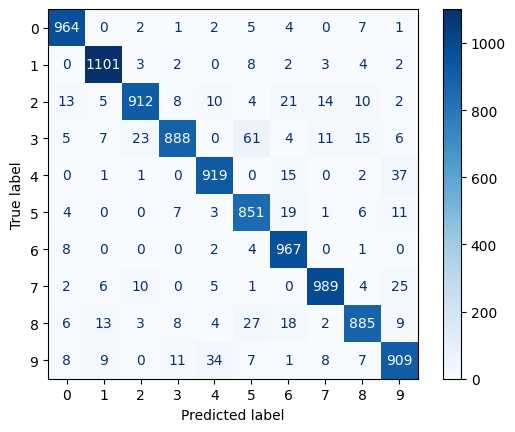

In [111]:
with torch.no_grad():
    y_pred = model_sgd(X_test)
    y_pred = np.argmax(y_pred.detach().cpu(), axis=1)
    accuracy = accuracy_score(y_pred, y_test)
    print(f"Final accuracy = {accuracy:.3f}")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.show()

In [112]:
def evaluate_k_models(models: list[MLP], x=X_test, y=y_test):
    fig, axs = plt.subplots(len(models), 2, figsize=(4*2, 4*len(models)))

    for fold, model in enumerate(models):
        ax = axs[fold, 0]
        ax.plot(np.arange(len(model.train_loss_per_epoch)), model.train_loss_per_epoch, label="train loss")
        ax.plot(np.arange(len(model.test_loss_per_epoch)), model.test_loss_per_epoch, label="test loss")
        ax.legend()
        ax.set_title(f"{fold=}")

        ax = axs[fold, 1]
        with torch.no_grad():
            y_pred = model(x)
            y_pred = np.argmax(y_pred.detach().cpu(), axis=1)
            accuracy = accuracy_score(y_pred, y)

        cm = confusion_matrix(y, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap="Blues", ax=ax)
        ax.set_title(f"{accuracy=}")

    plt.show()

In [113]:
models = train_models_5fold(10)

fold=0 epoch=0	CrossEntropy = 0.330
fold=0 epoch=1	CrossEntropy = 0.211
fold=0 epoch=2	CrossEntropy = 0.165
fold=0 epoch=3	CrossEntropy = 0.146
fold=0 epoch=4	CrossEntropy = 0.116
fold=0 epoch=5	CrossEntropy = 0.109
fold=0 epoch=6	CrossEntropy = 0.101
fold=0 epoch=7	CrossEntropy = 0.093
fold=0 epoch=8	CrossEntropy = 0.086
fold=0 epoch=9	CrossEntropy = 0.091
fold=1 epoch=0	CrossEntropy = 0.311
fold=1 epoch=1	CrossEntropy = 0.194
fold=1 epoch=2	CrossEntropy = 0.149
fold=1 epoch=3	CrossEntropy = 0.114
fold=1 epoch=4	CrossEntropy = 0.107
fold=1 epoch=5	CrossEntropy = 0.090
fold=1 epoch=6	CrossEntropy = 0.091
fold=1 epoch=7	CrossEntropy = 0.081
fold=1 epoch=8	CrossEntropy = 0.069
fold=1 epoch=9	CrossEntropy = 0.069
fold=2 epoch=0	CrossEntropy = 0.353
fold=2 epoch=1	CrossEntropy = 0.205
fold=2 epoch=2	CrossEntropy = 0.169
fold=2 epoch=3	CrossEntropy = 0.128
fold=2 epoch=4	CrossEntropy = 0.127
fold=2 epoch=5	CrossEntropy = 0.107
fold=2 epoch=6	CrossEntropy = 0.098
fold=2 epoch=7	CrossEntropy 

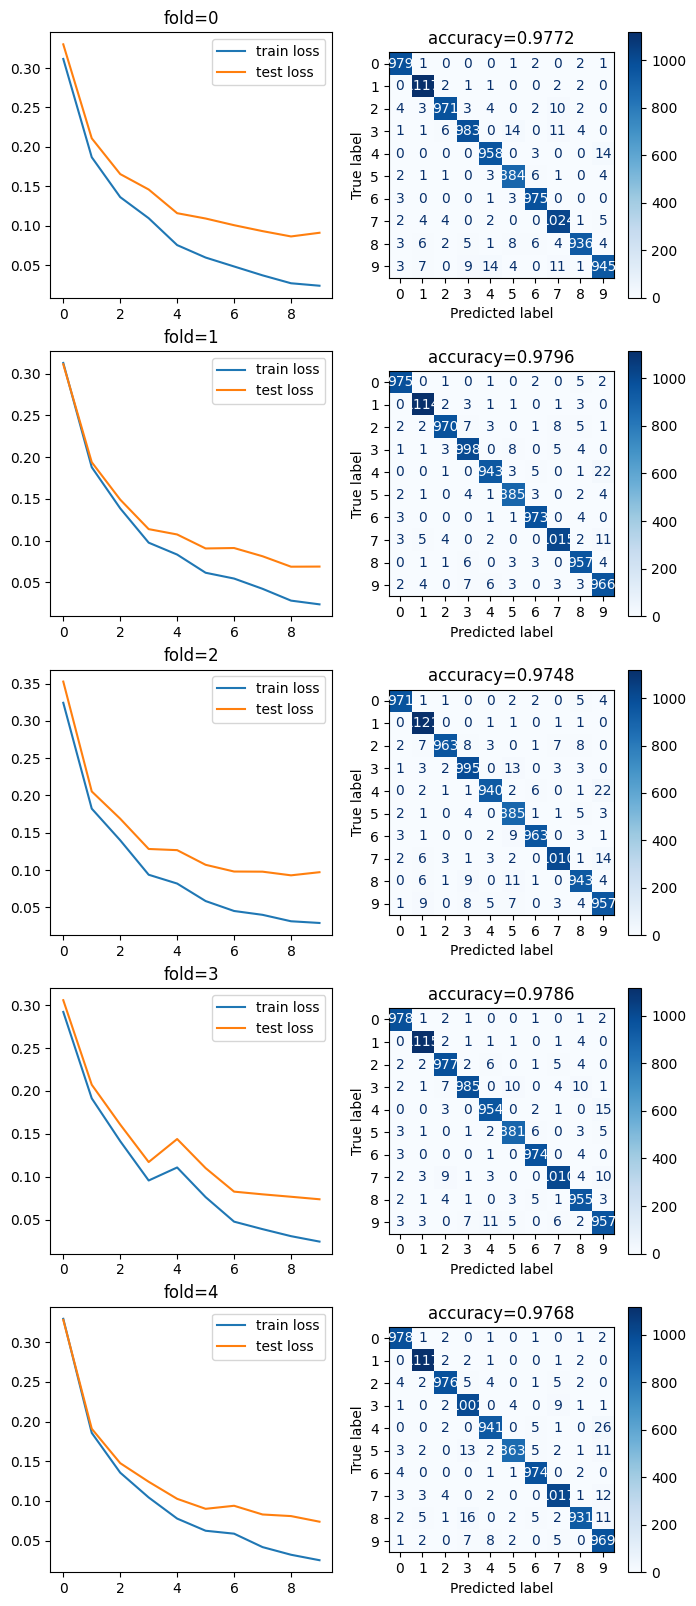

In [114]:
evaluate_k_models(models)

In [100]:
def majority_vote(models: list[MLP], x) -> tuple[int, float]:
    softmax_outputs = [model(x) for model in models]

    class_predictions = [torch.argmax(output, dim=1) for output in softmax_outputs]
    stacked_predictions = torch.stack(class_predictions, dim=0).flatten()
    majority_vote, _ = torch.mode(stacked_predictions, dim=0)

    num_models = len(models)
    vote_counts = torch.bincount(stacked_predictions)
    probs = vote_counts.float() / num_models

    # Filter out zeros to avoid log(0) issues
    probs = probs[probs > 0]

    # 4. Calculate Shannon Entropy (using log base 2)
    entropy = -torch.sum(probs * torch.log2(probs)).item()

    # 5. Normalize Entropy to a [0, 1] Confidence score
    # Max entropy for N outcomes is log2(N).
    # Confidence = 1 - (Current Entropy / Max Possible Entropy)
    max_entropy = torch.log2(torch.tensor(float(num_models))).item()
    confidence = 1.0 - (entropy / max_entropy)

    return majority_vote.item(), confidence

In [107]:
for idx, x in enumerate(X_test[:100]):
    vote, confidence = majority_vote(models, x.reshape(1, -1))

    if confidence != 1.0:
        print(f"{idx=}, {vote=}, {confidence=}")

idx=19, vote=3, confidence=0.34454123639780865
idx=48, vote=8, confidence=0.5818343233179366
idx=92, vote=0, confidence=0.6890824984659414


In [106]:
majority_vote(models, X_test[:8])

(1, 3.5840594270055095)

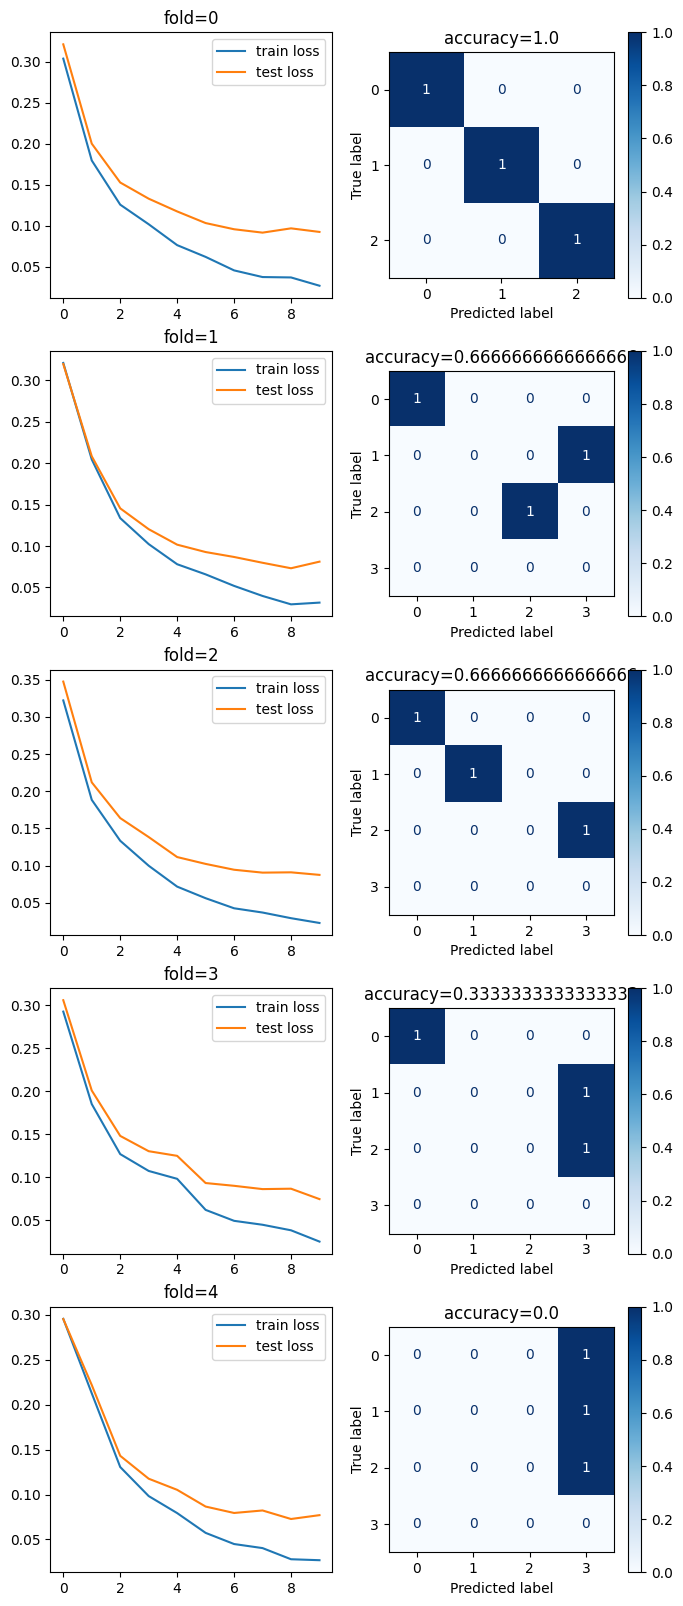

In [103]:
indicies = [19, 48, 92]
evaluate_k_models(models, X_test[indicies], y_test[indicies])